<a href="https://colab.research.google.com/github/arunpradeep-g/Python-Programs/blob/main/03_pima_indians_diabetes_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Create your first MLP in Keras
from keras.models import Sequential
from keras.layers import Dense
import numpy
import matplotlib.pyplot as plt

In [3]:
# fix random seed for reproducibility
numpy.random.seed(7)
# load pima indians dataset
dataset = numpy.loadtxt("https://raw.githubusercontent.com/arunpradeep-g/Python-Programs/refs/heads/main/pima-indians-diabetes.csv", delimiter=",")
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]

In [4]:
# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
model.fit(X, Y, epochs=150, batch_size=10)
# evaluate the model
scores = model.evaluate(X, Y)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

Epoch 1/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6523 - loss: 11.6107
Epoch 2/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6419 - loss: 3.4895
Epoch 3/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6315 - loss: 1.3119
Epoch 4/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6341 - loss: 1.0008
Epoch 5/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6185 - loss: 0.8824
Epoch 6/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6211 - loss: 0.7437
Epoch 7/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6146 - loss: 0.7019
Epoch 8/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6042 - loss: 0.7076
Epoch 9/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6159 - loss: 0.6833
Epoch 10/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6419 - loss: 0.6692
Epoch 11/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6341 - loss: 0.6655
Epoch 12/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [6]:
import numpy as np
# Predict diabetes for new samples (3 new patients)
samples = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50],   # Sample 1
                    [1, 85, 66, 29, 0, 26.6, 0.351, 31],    # Sample 2
                    [8, 183, 64, 0, 0, 23.3, 0.672, 32]])   # Sample 3

# Standardize the new data using the same scaler
#samples_scaled = scaler.transform(samples)

# Predict diabetes (returns probabilities)
predictions = model.predict(samples)

# Convert probabilities to class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int)

# Output predictions
print("Predictions for the samples (0 = No Diabetes, 1 = Diabetes):")
print(predicted_classes.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predictions for the samples (0 = No Diabetes, 1 = Diabetes):
[1 0 1]


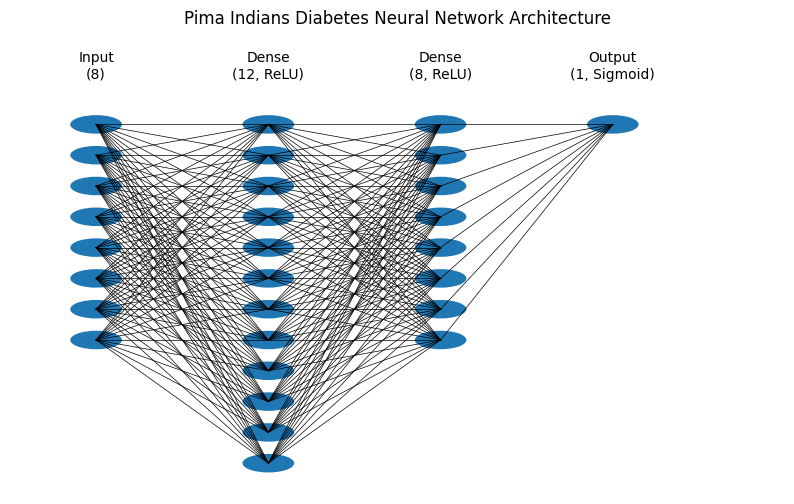

In [7]:
# Define layer sizes
layers = [8, 12, 8, 1]

fig, ax = plt.subplots(figsize=(10,6))

# Horizontal spacing
x_spacing = 2
# Vertical spacing
max_neurons = max(layers)

for i, layer_size in enumerate(layers):
    y_positions = range(max_neurons - layer_size, max_neurons)
    for j in range(layer_size):
        circle = plt.Circle((i * x_spacing, y_positions[j]), 0.3, fill=True)
        ax.add_patch(circle)
# Draw connections
for i in range(len(layers)-1):
    for j in range(layers[i]):
        for k in range(layers[i+1]):
            x1, y1 = i * x_spacing, max_neurons - layers[i] + j
            x2, y2 = (i+1) * x_spacing, max_neurons - layers[i+1] + k
            ax.plot([x1, x2], [y1, y2], 'k', linewidth=0.5)

# Labels
layer_names = ['Input\n(8)', 'Dense\n(12, ReLU)', 'Dense\n(8, ReLU)', 'Output\n(1, Sigmoid)']
for i, name in enumerate(layer_names):
    ax.text(i * x_spacing, max_neurons + 0.5, name, ha='center')

ax.set_xlim(-1, len(layers)*x_spacing)
ax.set_ylim(-1, max_neurons + 2)
ax.axis('off')

plt.title("Pima Indians Diabetes Neural Network Architecture")
plt.show()